# Olist E-commerce Data Analysis

## Project Objective

This project analyzes the Olist Brazilian e-commerce dataset to identify
business patterns, operational problems, and opportunities where Data & AI
could create value.

The analysis focuses on:

- Sales and product categories
- Delivery performance
- Late deliveries
- Customer satisfaction
- Seller performanceP
- Geographic delivery performance

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================

data_path = "data"

files = [
    file for file in os.listdir(data_path)
    if file.endswith(".csv")
]

print("CSV files found:")

for file in files:
    print("-", file)


# Load all CSV files
tables = {}

for file in files:
    table_name = file.replace(".csv", "")

    tables[table_name] = pd.read_csv(
        os.path.join(data_path, file)
    )

print("\nData loaded successfully!")

CSV files found:
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_orders_dataset.csv
- olist_order_items_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- product_category_name_translation.csv

Data loaded successfully!


In [3]:
# ============================================================
# 2. DATA UNDERSTANDING - BEFORE CLEANING
# ============================================================

print("\n" + "=" * 60)
print("BEFORE CLEANING")
print("=" * 60)


# Table sizes
print("\nTABLE SIZES")

for name, df in tables.items():
    print(name, ":", df.shape)


# Missing values
print("\nMISSING VALUES")

for name, df in tables.items():

    missing = df.isnull().sum()

    print("\n", name)

    if missing.sum() == 0:
        print("No missing values")
    else:
        print(missing[missing > 0])


# Duplicate rows
print("\nDUPLICATES")

for name, df in tables.items():
    print(name, ":", df.duplicated().sum())


BEFORE CLEANING

TABLE SIZES
olist_customers_dataset : (99441, 5)
olist_geolocation_dataset : (1000163, 5)
olist_orders_dataset : (99441, 8)
olist_order_items_dataset : (112650, 7)
olist_order_payments_dataset : (103886, 5)
olist_order_reviews_dataset : (99224, 7)
olist_products_dataset : (32951, 9)
olist_sellers_dataset : (3095, 4)
product_category_name_translation : (71, 2)

MISSING VALUES

 olist_customers_dataset
No missing values

 olist_geolocation_dataset
No missing values

 olist_orders_dataset
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

 olist_order_items_dataset
No missing values

 olist_order_payments_dataset
No missing values

 olist_order_reviews_dataset
review_comment_title      87656
review_comment_message    58247
dtype: int64

 olist_products_dataset
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
p

In [4]:
# ============================================================
# 3. DATA CLEANING
# ============================================================

clean_tables = {}

for name, df in tables.items():
    clean_tables[name] = df.copy()


# ------------------------------------------------------------
# Convert date columns
# ------------------------------------------------------------

date_columns = {
    "olist_orders_dataset": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ],

    "olist_order_items_dataset": [
        "shipping_limit_date"
    ],

    "olist_order_reviews_dataset": [
        "review_creation_date",
        "review_answer_timestamp"
    ]
}


for table_name, columns in date_columns.items():

    if table_name in clean_tables:

        for column in columns:

            clean_tables[table_name][column] = pd.to_datetime(
                clean_tables[table_name][column],
                errors="coerce"
            )


# ------------------------------------------------------------
# Remove duplicate geolocation records
# ------------------------------------------------------------

if "olist_geolocation_dataset" in clean_tables:

    clean_tables["olist_geolocation_dataset"] = (
        clean_tables["olist_geolocation_dataset"]
        .drop_duplicates()
    )


# ------------------------------------------------------------
# Clean product data
# ------------------------------------------------------------

if "olist_products_dataset" in clean_tables:

    products = clean_tables["olist_products_dataset"]

    products["product_category_name"] = (
        products["product_category_name"]
        .fillna("unknown")
    )

    numeric_columns = [
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]

    for column in numeric_columns:

        products[column] = products[column].fillna(
            products[column].median()
        )


# ------------------------------------------------------------
# Clean review text
# ------------------------------------------------------------

if "olist_order_reviews_dataset" in clean_tables:

    reviews = clean_tables["olist_order_reviews_dataset"]

    reviews["review_comment_title"] = (
        reviews["review_comment_title"]
        .fillna("No Title")
    )

    reviews["review_comment_message"] = (
        reviews["review_comment_message"]
        .fillna("No Message")
    )


# ------------------------------------------------------------
# Normalize city names
# ------------------------------------------------------------

city_columns = {
    "olist_customers_dataset": "customer_city",
    "olist_sellers_dataset": "seller_city",
    "olist_geolocation_dataset": "geolocation_city"
}


for table_name, column in city_columns.items():

    if table_name in clean_tables:

        clean_tables[table_name][column] = (
            clean_tables[table_name][column]
            .astype(str)
            .str.strip()
            .str.lower()
        )


print("\nCleaning completed successfully!")


Cleaning completed successfully!


In [5]:
# ============================================================
# 4. CHECK DATA AFTER CLEANING
# ============================================================

print("\n" + "=" * 60)
print("AFTER CLEANING")
print("=" * 60)


# Table sizes
print("\nTABLE SIZES")

for name, df in clean_tables.items():
    print(name, ":", df.shape)


# Missing values
print("\nMISSING VALUES")

for name, df in clean_tables.items():

    missing = df.isnull().sum()

    print("\n", name)

    if missing.sum() == 0:
        print("No missing values")
    else:
        print(missing[missing > 0])


# Duplicate rows
print("\nDUPLICATES")

for name, df in clean_tables.items():

    print(
        name,
        ":",
        df.duplicated().sum()
    )


AFTER CLEANING

TABLE SIZES
olist_customers_dataset : (99441, 5)
olist_geolocation_dataset : (738332, 5)
olist_orders_dataset : (99441, 8)
olist_order_items_dataset : (112650, 7)
olist_order_payments_dataset : (103886, 5)
olist_order_reviews_dataset : (99224, 7)
olist_products_dataset : (32951, 9)
olist_sellers_dataset : (3095, 4)
product_category_name_translation : (71, 2)

MISSING VALUES

 olist_customers_dataset
No missing values

 olist_geolocation_dataset
No missing values

 olist_orders_dataset
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

 olist_order_items_dataset
No missing values

 olist_order_payments_dataset
No missing values

 olist_order_reviews_dataset
No missing values

 olist_products_dataset
No missing values

 olist_sellers_dataset
No missing values

 product_category_name_translation
No missing values

DUPLICATES
olist_customers_dataset : 0
olist_geolocation_dataset : 0
olist_orders_d

In [6]:
# ============================================================
# 5. PRIMARY KEYS & RELATIONSHIPS
# ============================================================

print("\n" + "=" * 60)
print("PRIMARY KEY CHECK")
print("=" * 60)

primary_keys = {
    "olist_customers_dataset": "customer_id",
    "olist_orders_dataset": "order_id",
    "olist_products_dataset": "product_id",
    "olist_sellers_dataset": "seller_id",
    "product_category_name_translation": "product_category_name"
}

for table_name, key in primary_keys.items():
    if table_name in clean_tables:
        df = clean_tables[table_name]
        duplicate_keys = df[key].duplicated().sum()
        missing_keys = df[key].isnull().sum()

        if duplicate_keys == 0 and missing_keys == 0:
            print(table_name, ": PRIMARY KEY OK")
        else:
            print(
                table_name,
                ": PROBLEM",
                "| Duplicate:", duplicate_keys,
                "| Missing:", missing_keys
            )

# ============================================================
# RELATIONSHIPS
# ============================================================

print("\n" + "=" * 60)
print("RELATIONSHIPS")
print("=" * 60)

orders = clean_tables["olist_orders_dataset"]
customers = clean_tables["olist_customers_dataset"]
items = clean_tables["olist_order_items_dataset"]
products = clean_tables["olist_products_dataset"]
sellers = clean_tables["olist_sellers_dataset"]
payments = clean_tables["olist_order_payments_dataset"]
reviews = clean_tables["olist_order_reviews_dataset"]

print("\nOrders → Customers")
print("Matching:", orders["customer_id"].isin(customers["customer_id"]).sum())

print("\nOrder Items → Orders")
print("Matching:", items["order_id"].isin(orders["order_id"]).sum())

print("\nOrder Items → Products")
print("Matching:", items["product_id"].isin(products["product_id"]).sum())

print("\nOrder Items → Sellers")
print("Matching:", items["seller_id"].isin(sellers["seller_id"]).sum())

print("\nPayments → Orders")
print("Matching:", payments["order_id"].isin(orders["order_id"]).sum())

print("\nReviews → Orders")
print("Matching:", reviews["order_id"].isin(orders["order_id"]).sum())

print("\nRelationships check completed!")



PRIMARY KEY CHECK
olist_customers_dataset : PRIMARY KEY OK
olist_orders_dataset : PRIMARY KEY OK
olist_products_dataset : PRIMARY KEY OK
olist_sellers_dataset : PRIMARY KEY OK
product_category_name_translation : PRIMARY KEY OK

RELATIONSHIPS

Orders → Customers
Matching: 99441

Order Items → Orders
Matching: 112650

Order Items → Products
Matching: 112650

Order Items → Sellers
Matching: 112650

Payments → Orders
Matching: 103886

Reviews → Orders
Matching: 99224

Relationships check completed!


# Business Questions

The analysis focuses on the following business questions:

1. Which product categories generate the highest sales value?
2. How long does delivery typically take?
3. How common are late deliveries?
4. Is late delivery associated with lower customer satisfaction?
5. Are delivery delays concentrated among certain sellers?
6. Does delivery performance vary across customer states?


TOP 10 PRODUCT CATEGORIES BY SALES
product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

CATEGORY SUMMARY - TOP 10
                        total_sales  items_sold  average_price
product_category_name                                         
beleza_saude             1258681.34        9670     130.163531
relogios_presentes       1205005.68        5991     201.135984
cama_mesa_banho          1036988.68       11115      93.296327
esporte_lazer             988048.97        8641     114.344285
informatica_acessorios    911954.32        7827     116.513903
moveis_decoracao          729762.49        8334      87.564494
cool_stuff   

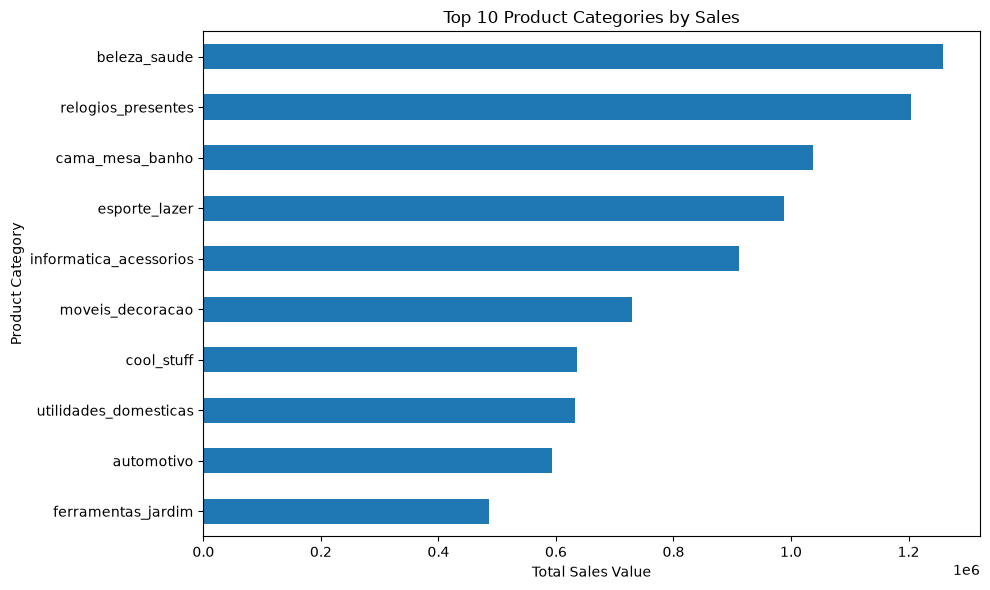

In [7]:
# ============================================================
# 6. EDA - SALES & PRODUCT CATEGORIES
# ============================================================

items = clean_tables["olist_order_items_dataset"]
products = clean_tables["olist_products_dataset"]

# Combine order items with product information
sales = items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# Calculate total sales by category
sales_by_category = (
    sales.groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP 10 PRODUCT CATEGORIES BY SALES")
print(sales_by_category.head(10))

# Create category summary
category_summary = (
    sales.groupby("product_category_name")
    .agg(
        total_sales=("price", "sum"),
        items_sold=("product_id", "count"),
        average_price=("price", "mean")
    )
    .sort_values("total_sales", ascending=False)
)

print("\nCATEGORY SUMMARY - TOP 10")
print(category_summary.head(10))

# Visualization
top_10 = category_summary.head(10)


top_10["total_sales"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Total Sales Value")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# 7. EDA - DELIVERY PERFORMANCE
# ============================================================

orders = clean_tables["olist_orders_dataset"]


# Keep orders that were actually delivered
delivered_orders = orders.dropna(
    subset=[
        "order_delivered_customer_date",
        "order_purchase_timestamp"
    ]
).copy()


# Calculate delivery time
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days


print("\nDELIVERY PERFORMANCE")

print(
    "Delivered orders:",
    len(delivered_orders)
)

print(
    "Average delivery time:",
    round(
        delivered_orders["delivery_days"].mean(),
        2
    ),
    "days"
)

print(
    "Median delivery time:",
    delivered_orders["delivery_days"].median(),
    "days"
)


# ============================================================
# LATE DELIVERY
# ============================================================

delivery_check = delivered_orders.copy()


delivery_check["late_delivery"] = (
    delivery_check["order_delivered_customer_date"]
    > delivery_check["order_estimated_delivery_date"]
)


late_orders = delivery_check["late_delivery"].sum()
total_orders = len(delivery_check)

late_percentage = (
    late_orders / total_orders
) * 100


print("\nLATE DELIVERY")

print("Late orders:", late_orders)
print("Total delivered orders:", total_orders)

print(
    "Late delivery percentage:",
    round(late_percentage, 2),
    "%"
)


DELIVERY PERFORMANCE
Delivered orders: 96476
Average delivery time: 12.09 days
Median delivery time: 10.0 days

LATE DELIVERY
Late orders: 7827
Total delivered orders: 96476
Late delivery percentage: 8.11 %


# Delivery Findings

- The dataset contains 96,476 delivered orders with both purchase and delivery dates.
- Average delivery time was approximately 12.09 days.
- Median delivery time was 10 days.
- 8.11% of delivered orders arrived after the estimated delivery date.

### Business Interpretation

Delivery delays represent a measurable operational issue and may affect the customer experience.

In [9]:
# ============================================================
# 8. EDA - DELIVERY DELAY VS CUSTOMER SATISFACTION
# ============================================================

reviews = clean_tables["olist_order_reviews_dataset"]


# Check duplicate reviews per order
duplicate_reviews = (
    reviews["order_id"]
    .duplicated()
    .sum()
)

print("\nDUPLICATE REVIEWS CHECK")
print(
    "Duplicate review order IDs:",
    duplicate_reviews
)


# Create one review score per order
reviews_per_order = (
    reviews
    .groupby("order_id")["review_score"]
    .mean()
    .reset_index()
)


# Merge reviews with delivery information
review_delivery_clean = delivery_check.merge(
    reviews_per_order,
    on="order_id",
    how="inner"
)


# Compare satisfaction
satisfaction_clean = (
    review_delivery_clean
    .groupby("late_delivery")["review_score"]
    .mean()
)


print("\nCUSTOMER SATISFACTION - CLEANED")

print(
    "Average review score - On time:",
    round(
        satisfaction_clean.get(False),
        2
    )
)

print(
    "Average review score - Late:",
    round(
        satisfaction_clean.get(True),
        2
    )
)


DUPLICATE REVIEWS CHECK
Duplicate review order IDs: 551

CUSTOMER SATISFACTION - CLEANED
Average review score - On time: 4.29
Average review score - Late: 2.57


In [10]:
# ============================================================
# 9. EDA - SELLER DELIVERY PERFORMANCE
# ============================================================

items = clean_tables["olist_order_items_dataset"]


# One seller-order combination
seller_orders = (
    items[
        ["order_id", "seller_id"]
    ]
    .drop_duplicates()
)


seller_delivery = seller_orders.merge(
    delivery_check[
        ["order_id", "late_delivery"]
    ],
    on="order_id",
    how="inner"
)


seller_performance = (
    seller_delivery
    .groupby("seller_id")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("late_delivery", "sum"),
        late_rate=("late_delivery", "mean")
    )
)


seller_performance["late_rate"] = (
    seller_performance["late_rate"] * 100
)


seller_performance_50 = (
    seller_performance[
        seller_performance["total_orders"] >= 50
    ]
    .sort_values(
        "late_rate",
        ascending=False
    )
)


print("\nSELLER DELIVERY PERFORMANCE")

print(
    seller_performance_50.head(10)
)


# ============================================================
# 10. EDA - DELIVERY PERFORMANCE BY CUSTOMER STATE
# ============================================================

customers = clean_tables["olist_customers_dataset"]


state_delivery = delivery_check.merge(
    customers[
        ["customer_id", "customer_state"]
    ],
    on="customer_id",
    how="left"
)


state_performance = (
    state_delivery
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("late_delivery", "sum"),
        late_rate=("late_delivery", "mean")
    )
)


state_performance["late_rate"] = (
    state_performance["late_rate"] * 100
)


state_performance_100 = (
    state_performance[
        state_performance["total_orders"] >= 100
    ]
    .sort_values(
        "late_rate",
        ascending=False
    )
)


print("\nDELIVERY PERFORMANCE BY CUSTOMER STATE")

print(
    state_performance_100
)


SELLER DELIVERY PERFORMANCE
                                  total_orders  late_orders  late_rate
seller_id                                                             
54965bbe3e4f07ae045b90b0b8541f52            73           22  30.136986
a49928bcdf77c55c6d6e05e09a9b4ca5            96           25  26.041667
beadbee30901a7f61d031b6b686095ad            64           16  25.000000
06a2c3af7b3aee5d69171b0e14f0ee87           389           90  23.136247
cac4c8e7b1ca6252d8f20b2fc1a2e4af            74           17  22.972973
6039e27294dc75811c0d8a39069f52c0            63           14  22.222222
1ca7077d890b907f89be8c954a02686a           108           24  22.222222
712e6ed8aa4aa1fa65dab41fed5737e4            77           17  22.077922
ea566164622c6b439516ab18062c42cd            50           11  22.000000
d13e50eaa47b4cbe9eb81465865d8cfc            66           14  21.212121

DELIVERY PERFORMANCE BY CUSTOMER STATE
                total_orders  late_orders  late_rate
customer_state            

# Seller & Geographic Findings

### Finding 5 — Seller Performance

Among sellers with at least 50 orders, some sellers had late-delivery rates above 20%, with the highest observed rate around 30%.

This suggests that seller-level performance monitoring could help identify operational risks earlier.

### Finding 6 — Geographic Performance

Among customer states with at least 100 delivered orders, late-delivery rates ranged from approximately 2.9% to 23.9%.

This suggests that geographic and logistics factors may be relevant to delivery performance and should be considered in delivery-risk analysis.


# Key Findings, Business Interpretation & HVIA Solution

## Key Findings

### Finding 1 — Product Categories

Beauty & Health had the highest total sales value among the top categories. Watches & Gifts achieved similar sales with fewer items because of its higher average product price.

### Finding 2 — Sales Drivers

Product categories generate sales in different ways. Some categories depend more on sales volume, while others have higher average product prices.

### Finding 3 — Late Delivery

8.11% of delivered orders arrived after the estimated delivery date.

### Finding 4 — Customer Satisfaction

Late deliveries were strongly associated with lower customer review scores:

- On-time orders: 4.29 / 5
- Late orders: 2.57 / 5
- Difference: 1.72 points

This analysis shows an association and does not establish causality.

### Finding 5 — Seller Performance

Among sellers with at least 50 orders, some sellers had late-delivery rates above 20%, with the highest observed rate around 30%.

This suggests that seller-level performance monitoring could help identify operational risks.

### Finding 6 — Geographic Performance

Among customer states with at least 100 delivered orders, late-delivery rates ranged from approximately 2.9% to 23.9%.

This suggests that geographic and logistics factors may be relevant to delivery performance.

## Business Interpretation

The analysis indicates that delivery performance is an important operational and customer-experience area for Olist.

The main business opportunity is to identify delivery risks earlier, monitor seller performance, and understand where delivery problems are concentrated.

## HVIA Solution Proposal

### Delivery Risk Intelligence Platform

HVIA could provide a Data & AI solution with three main capabilities:

**1. Predict**

Use historical order, seller, product, and geographic data to predict the probability that an order will be delivered late.

**2. Monitor**

Provide dashboards for:

- Late-delivery rate
- Seller performance
- Geographic performance
- Average delivery time
- High-risk orders

**3. Alert**

Identify high-risk orders before the expected delivery date so operational teams can investigate or intervene earlier.

## Potential Business Value

The solution could help Olist with:

- Earlier identification of delivery risks
- Better seller performance visibility
- More targeted operational intervention
- Improved customer experience
- Predictive logistics analytics
- Better use of existing operational data
